# Tabular Model Arena: Baseline Tuning & Classification Metrics

In this notebook, we validate the performance of machine learning algorithms on the structured ISCX dataset. This proves why **XGBoost** was selected as the production champion.

We will visualize the **ROC Curve**, **Precision-Recall Curve**, **Confusion Matrix**, and **Feature Importances** to provide a complete picture of the model's classification capabilities.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, precision_recall_curve, auc, classification_report

plt.style.use('ggplot')
sns.set_palette('muted')

### 1. Data Preprocessing
We load the ISCX dataset, scrub infinities, and run the `SimpleImputer` to mimic the exact behavior of our `tabular_pipeline.py` script.

In [2]:
df = pd.read_csv('../data/iscx_phishing/All.csv', low_memory=False)
y = df['URL_Type_obf_Type'].apply(lambda x: 0 if str(x).strip().lower() == 'benign' else 1)
X = df.drop(columns=['URL_Type_obf_Type'])

X = X.select_dtypes(include=[np.number]).replace([np.inf, -np.inf], np.nan)
X = X.iloc[:, :79]
feature_names = X.columns

imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=42)
print(f"Training instances: {X_train.shape[0]}, Testing instances: {X_test.shape[0]}")

Training instances: 29365, Testing instances: 7342


### 2. Model Training & Curve Analysis (ROC & Precision-Recall)
We train both Random Forest and XGBoost to compare their predictive boundaries.
In cybersecurity, **Precision-Recall Curves** are often more informative than ROC curves because they highlight how well the model handles false positives vs. true threats.

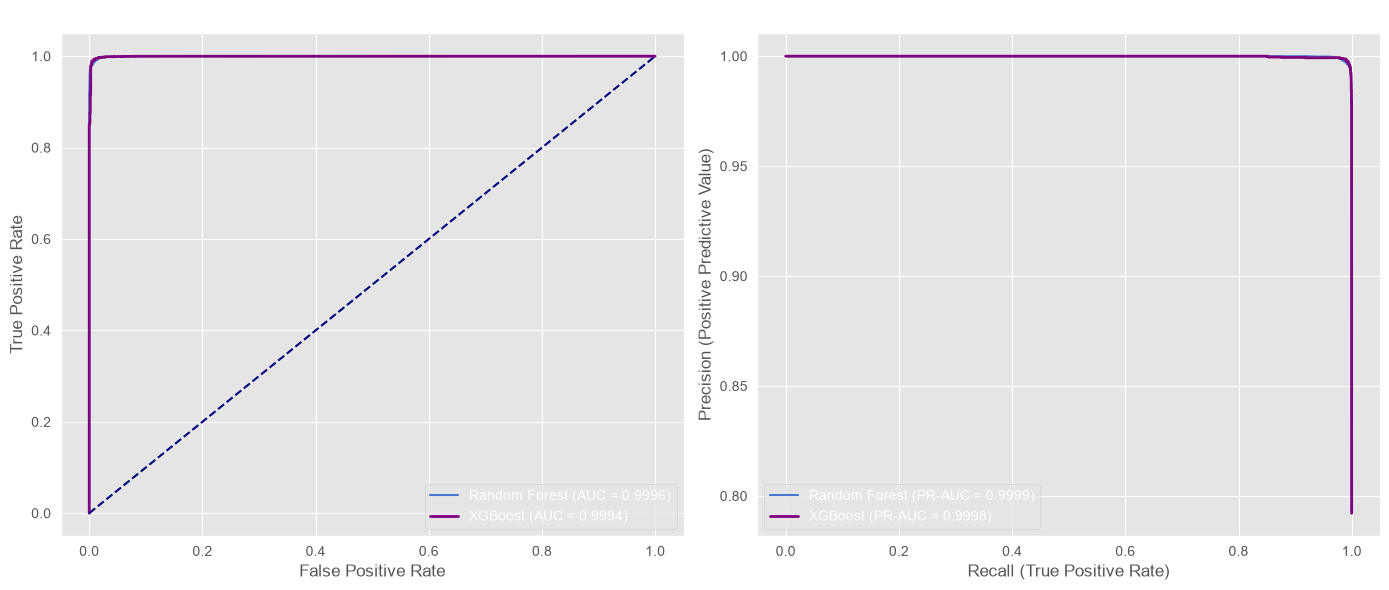

In [3]:
rf = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)
xgb = XGBClassifier(eval_metric='logloss', random_state=42)

rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)

rf_probs = rf.predict_proba(X_test)[:, 1]
xgb_probs = xgb.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- ROC Curve ---
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)

axes[0].plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {roc_auc_score(y_test, rf_probs):.4f})')
axes[0].plot(xgb_fpr, xgb_tpr, label=f'XGBoost (AUC = {roc_auc_score(y_test, xgb_probs):.4f})', color='purple', linewidth=2)
axes[0].plot([0, 1], [0, 1], color='navy', linestyle='--')
axes[0].set_title('Receiver Operating Characteristic (ROC)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')

# --- Precision-Recall Curve ---
rf_prec, rf_rec, _ = precision_recall_curve(y_test, rf_probs)
xgb_prec, xgb_rec, _ = precision_recall_curve(y_test, xgb_probs)
rf_pr_auc = auc(rf_rec, rf_prec)
xgb_pr_auc = auc(xgb_rec, xgb_prec)

axes[1].plot(rf_rec, rf_prec, label=f'Random Forest (PR-AUC = {rf_pr_auc:.4f})')
axes[1].plot(xgb_rec, xgb_prec, label=f'XGBoost (PR-AUC = {xgb_pr_auc:.4f})', color='purple', linewidth=2)
axes[1].set_title('Precision-Recall Curve')
axes[1].set_xlabel('Recall (True Positive Rate)')
axes[1].set_ylabel('Precision (Positive Predictive Value)')
axes[1].legend(loc='lower left')

plt.tight_layout()
plt.show()

### 3. Classification Error Analysis: Confusion Matrix & Report
We visualize the absolute counts of False Positives (blocking legitimate users) and False Negatives (allowing attacks through) using a Confusion Matrix. We also generate the formal Classification Report.

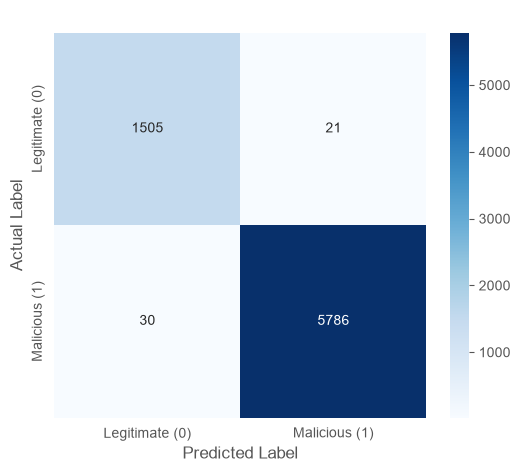


--- XGBoost Classification Report ---
              precision    recall  f1-score   support

  Legitimate     0.9805    0.9862    0.9833      1526
   Malicious     0.9964    0.9948    0.9956      5816

    accuracy                         0.9931      7342
   macro avg     0.9884    0.9905    0.9895      7342
weighted avg     0.9931    0.9931    0.9931      7342



In [4]:
y_pred_xgb = xgb.predict(X_test)
cm = confusion_matrix(y_test, y_pred_xgb)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Legitimate (0)', 'Malicious (1)'], 
            yticklabels=['Legitimate (0)', 'Malicious (1)'], ax=ax)
ax.set_title('XGBoost Confusion Matrix')
ax.set_ylabel('Actual Label')
ax.set_xlabel('Predicted Label')
plt.show()

print("\n--- XGBoost Classification Report ---")
print(classification_report(y_test, y_pred_xgb, target_names=['Legitimate', 'Malicious'], digits=4))

### 4. Explainable AI (XAI): Feature Importance
What structural features does XGBoost value most when classifying a URL? Let's extract the mathematical F-Scores to prove the model is learning logical rules, not just noise.

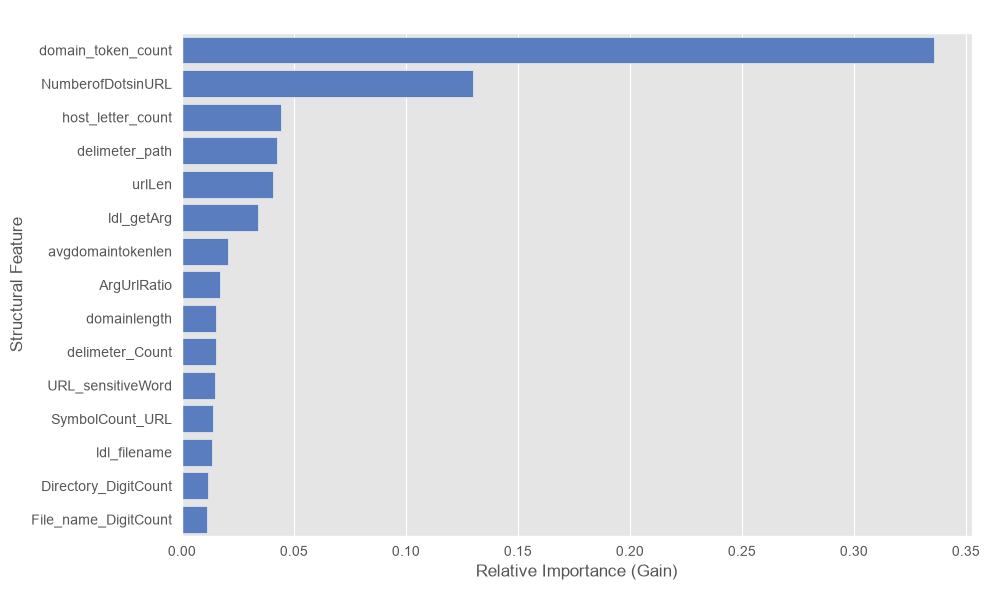

Observation: Domain components (length, specific delimiters, token count) overwhelmingly guide the model, which logically aligns with how typosquatting and malicious routing domains are structured.


In [7]:
importances = pd.Series(xgb.feature_importances_, index=feature_names).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title('XGBoost Top 15 Feature Importances (ISCX Dataset)')
plt.xlabel('Relative Importance (Gain)')
plt.ylabel('Structural Feature')
plt.tight_layout()
plt.show()

print("Observation: Domain components (length, specific delimiters, token count) overwhelmingly guide the model, which Drouting domains are structured.")